In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pre-processing

In [3]:
files = os.listdir('res/latency')
df2 = pd.read_csv(f'res/latency/latency_2_layers.csv')
df3 = pd.read_csv(f'res/latency/latency_3_layers.csv')

In [4]:
df2

,network_size,ring_size,128_security,total_time,model_enc_time,data_enc_time,fwd_time,bwd_time,bs_time
0,64-32-32,32,False,77.352,0.308,0.296,2.652,10.027,64.069
1,128-64-64,32,False,80.086,0.288,0.344,3.097,10.120,66.237
2,64-32-32,64,True,202.292,0.383,0.511,4.465,9.768,187.165
3,128-64-64,64,True,212.638,0.359,0.465,5.388,29.324,177.102
4,256-128-128,64,True,209.196,0.369,0.753,5.262,18.479,184.333
5,512-64-64,64,True,198.023,0.385,0.500,4.484,17.620,175.034
6,256-256-256,128,True,486.933,0.844,0.959,10.992,39.564,434.574
7,512-128-128,128,True,471.370,0.812,1.397,11.109,34.490,423.562


In [5]:
df3

,network_size,ring_size,128_security,total_time,model_enc_time,data_enc_time,fwd_time,bwd_time,bs_time
0,64-32-32-32,32,False,102.716,0.615,0.264,5.793,14.476,81.568
1,128-64-64-64,32,False,106.533,0.638,0.245,3.734,15.071,86.845
2,64-32-32-32,64,True,261.052,0.755,0.781,8.734,26.352,224.430
3,128-64-64-64,64,True,256.327,0.760,0.771,7.783,26.944,220.069
4,256-128-128-128,64,True,247.666,0.787,0.499,9.348,26.905,210.127
5,512-64-64-64,64,True,244.965,0.815,0.740,8.597,27.626,207.187
6,256-256-256-256,128,True,627.190,2.175,1.176,18.386,53.651,551.802
7,512-128-128-128,128,True,621.537,1.187,1.041,18.007,50.124,551.178


# Plot

In [6]:
params = {
   'font.size': 26,
   'axes.linewidth': 1.25,
   'axes.labelsize': 26,
   'legend.fontsize': 22,
   'xtick.labelsize': 22,
   'ytick.labelsize': 22,
}
plt.rcParams.update(params)

In [8]:
x_label = 'Polynomial degree $N$'
y_label = 'Training iteration time (s)'
legend_labels = ['2 hidden layers', '3 hidden layers']

In [9]:
from palettable.colorbrewer.qualitative import Set2_4
colors = Set2_4.mpl_colors

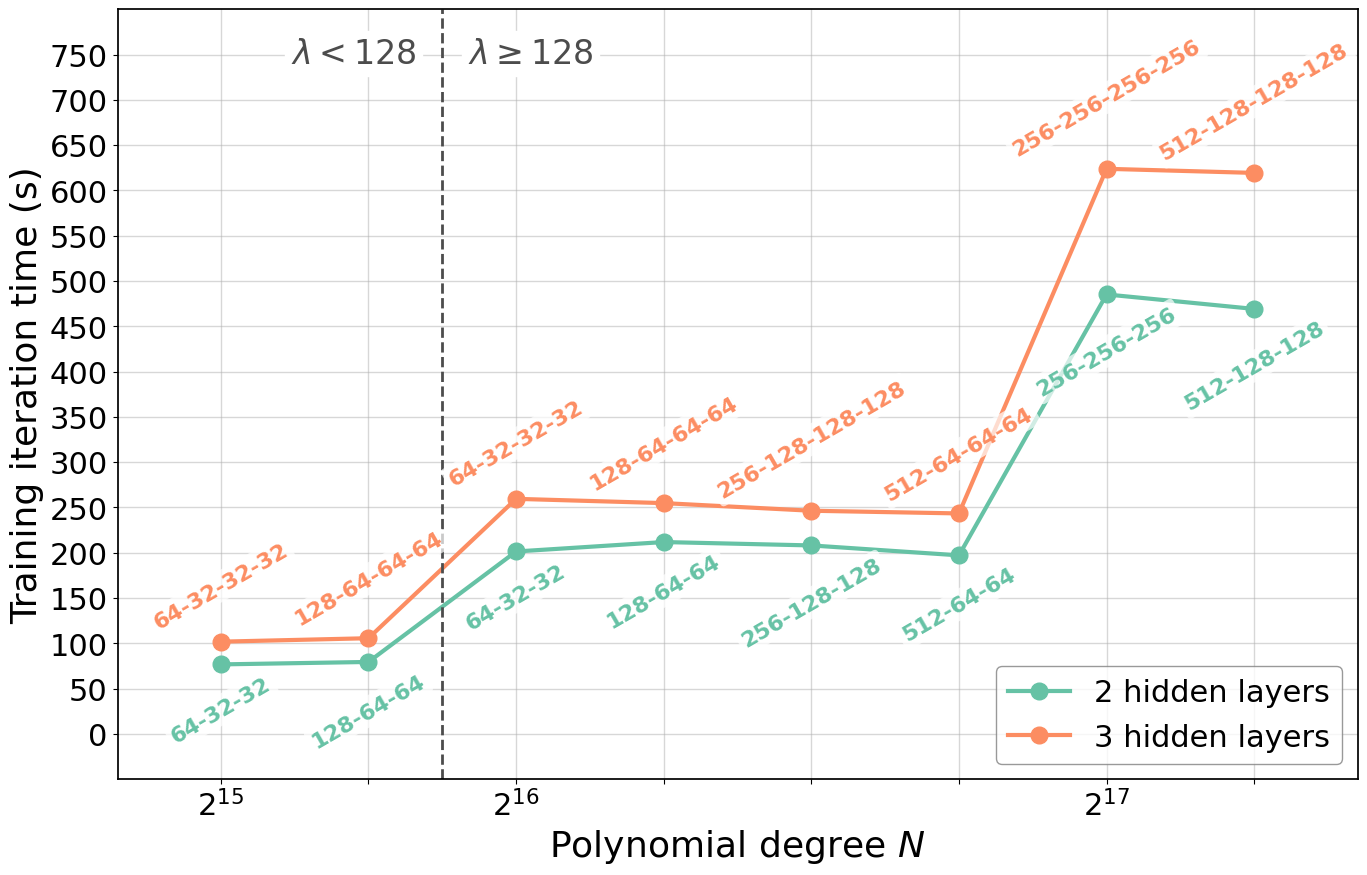

In [10]:
# Calculate the step time for each sample in df2 and df3
step_time_2 = df2['total_time'] - df2['data_enc_time'] - df2['model_enc_time']
step_time_3 = df3['total_time'] - df3['data_enc_time'] - df3['model_enc_time']

network_size_2 = df2['network_size']
network_size_3 = df3['network_size']

# # Add a fake sample for both layer 2 and layer 3 before the last two samples to align them
# inserted_2 = False
# if not inserted_2:
#     insert_idx = 7  # before the last two samples
#     step_time_2 = np.insert(step_time_2, insert_idx, np.nan)
#     network_size_2 = np.insert(network_size_2, insert_idx, 'fake')
#     inserted_2 = True

# inserted_3 = False
# if not inserted_3:
#     insert_idx = 4
#     step_time_3 = np.insert(step_time_3, insert_idx, np.nan)
#     network_size_3 = np.insert(network_size_3, insert_idx, 'fake')
#     inserted_3 = True

x_2 = np.arange(len(step_time_2))
x_3 = np.arange(len(step_time_3))

# Use ring_dimension for xticks and show x-axis label
ring_dim_2 = df2['ring_size']
ring_dim_3 = df3['ring_size']

# Convert ring dimension values to LaTeX format
ring_map = {32: r'$2^{15}$', 64: r'$2^{16}$', 128: r'$2^{17}$'}
ring_dim_2 = [ring_map.get(int(x), '') for x in ring_dim_2]
ring_dim_3 = [ring_map.get(int(x), '') for x in ring_dim_3]

# # After inserting fake samples, update ring_dimension arrays
# ring_dim_2 = np.insert(ring_dim_2, 7, '')  # insert empty label for fake sample
# ring_dim_3 = np.insert(ring_dim_3, 4, '')  # insert empty label for fake sample

xtick_labels = ring_dim_2 if len(ring_dim_2) >= len(ring_dim_3) else ring_dim_3

# Make each label appear only the first time it changes
unique_xtick_labels = []
prev_label = None
for label in xtick_labels:
    if label != prev_label:
        unique_xtick_labels.append(label)
        prev_label = label
    else:
        unique_xtick_labels.append('')

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlabel(x_label)  # Show x label
ax.set_ylabel(y_label)

font_size = 16
font_rotation = 30
offset = 10

# Plot for df2: equidistant x, step_time on y (skip NaN for plotting, but keep for annotation)
valid_idx_2 = ~np.isnan(step_time_2)
ax.plot(x_2[valid_idx_2], step_time_2[valid_idx_2], label=legend_labels[0], linewidth=3, color=colors[0], marker='o', markersize=12)
for x, y, nsize in zip(x_2, step_time_2, network_size_2):
    if not (isinstance(y, float) and np.isnan(y)):
        ax.text(x, y - offset, str(nsize), ha='center', va='top', fontsize=font_size, fontweight='bold', color=colors[0], rotation=font_rotation, bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))

# Plot for df3: equidistant x, step_time on y (skip NaN for plotting, but keep for annotation)
valid_idx_3 = ~np.isnan(step_time_3)
ax.plot(x_3[valid_idx_3], step_time_3[valid_idx_3], label=legend_labels[1], linewidth=3, color=colors[1], marker='o', markersize=12)
for x, y, nsize in zip(x_3, step_time_3, network_size_3):
    if not (isinstance(y, float) and np.isnan(y)):
        ax.text(x, y + offset, str(nsize), ha='center', va='bottom', fontsize=font_size, fontweight='bold', color=colors[1], rotation=font_rotation, bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))

# Draw vertical lines and annotate sections
ax.axvline(x=1.5, color="#4C4C4C", linestyle='--', linewidth=2)
ax.text(0.9, ax.get_ylim()[1] + 100, '$\lambda < 128$', ha='center', va='center', fontsize=24, color='#4C4C4C', rotation=0, backgroundcolor='white')
ax.text(2.1, ax.get_ylim()[1] + 100, '$\lambda \geq 128$', ha='center', va='center', fontsize=24, color='#4C4C4C', rotation=0, backgroundcolor='white')

ax.tick_params(axis='x', bottom=True, labelbottom=True)  # Show xticks for each sample, but no labels
ax.set_xticks(np.arange(max(len(x_2), len(x_3))))
ax.set_xticklabels(unique_xtick_labels)
ax.tick_params(axis='x', bottom=True, labelbottom=True)
ax.tick_params(axis='y')
ax.set_ylim(-50, 800)
ax.set_yticks(np.arange(0, 800, 50))  # Add more yticks, every 50 units

# Slightly increase the xlim to the left and right
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min - 0.35, x_max + 0.35)

legend = ax.legend(loc='lower right')
frame = legend.get_frame()
frame.set_edgecolor('0.5')
ax.grid(linewidth=1, alpha=0.5, axis='both')

In [11]:
from pathlib import Path

fn = Path(f'out/latency.pdf')
fig.savefig(fn, bbox_inches='tight')